In [1]:
import json

import pandas as pd
import modules.distribution_plotting as dist

from pathlib import Path

# Extraction Distribution

In [2]:
BRT_PRED_PATH = Path("../data/results/final/biored_test/biored_test_predictions.json")
CBC_PRED_PATH = Path("../data/results/final/contemporary/contemporary_predictions.json")

BRT_ENT_GT = Path("../data/processed/biored/br_test_entities.csv")
CBC_ENT_GT = Path("../data/processed/contemporary/cbc_ner_gt.csv")

BRT_REL_GT = Path("../data/processed/biored/br_test_entity_relations.csv")
CBC_REL_GT = Path("../data/processed/contemporary/cbc_re_gt.csv")

with open(BRT_PRED_PATH, "r") as f:
    brt_pred = json.load(f)

with open(CBC_PRED_PATH, "r") as f:
    cbc_pred = json.load(f)

In [3]:
brt_entities = pd.DataFrame(brt_pred["entities"])
cbc_entities = pd.DataFrame(cbc_pred["entities"])

brt_relations = pd.DataFrame(brt_pred["relations"])
cbc_relations = pd.DataFrame(cbc_pred["relations"])

brt_gt_entities = pd.read_csv(BRT_ENT_GT)
cbc_gt_entities = pd.read_csv(CBC_ENT_GT)

brt_gt_relations = pd.read_csv(BRT_REL_GT)
cbc_gt_relations = pd.read_csv(CBC_REL_GT)

downsampled_abstracts = pd.read_csv("../data/processed/contemporary/cbc_downsampled_abstracts.csv")
downsampled_pmids = set(downsampled_abstracts["pmid"])

cbc_entities_subset = cbc_entities[cbc_entities["pmid"].isin(downsampled_pmids)]
cbc_relations_subset = cbc_relations[cbc_relations["pmid"].isin(downsampled_pmids)]

e:\Users\wesle\biomedical_kg_thesis\FINAL_pipeline\modules\distribution_plotting.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"{abs(int(x))}" for x in xticks])
e:\Users\wesle\biomedical_kg_thesis\FINAL_pipeline\modules\distribution_plotting.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"{abs(int(x))}" for x in xticks])


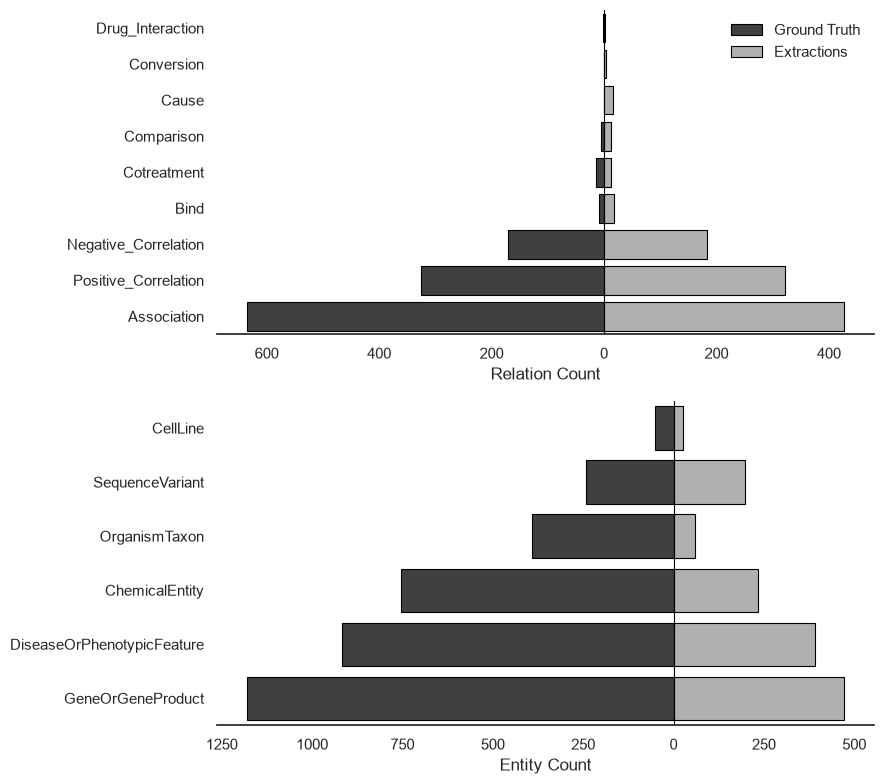

In [4]:
fig, axes = dist.plot_distribution_comparison(
    gt_entities=brt_gt_entities,
    pred_entities=brt_entities,
    gt_relations=brt_gt_relations,
    pred_relations=brt_relations,
)

e:\Users\wesle\biomedical_kg_thesis\FINAL_pipeline\modules\distribution_plotting.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"{abs(int(x))}" for x in xticks])
e:\Users\wesle\biomedical_kg_thesis\FINAL_pipeline\modules\distribution_plotting.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"{abs(int(x))}" for x in xticks])


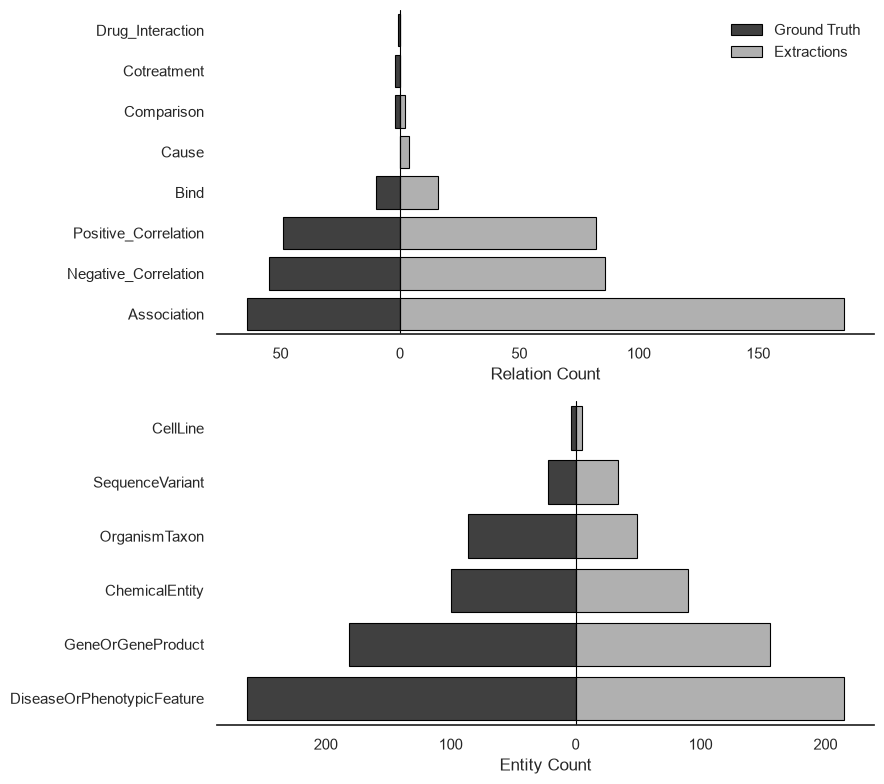

In [5]:
fig, axes = dist.plot_distribution_comparison(
    gt_entities=cbc_gt_entities,
    pred_entities=cbc_entities_subset,
    gt_relations=cbc_gt_relations,
    pred_relations=cbc_relations_subset,
)

# Error Distribution

# Ground Truth Distribution

e:\Users\wesle\biomedical_kg_thesis\FINAL_pipeline\modules\distribution_plotting.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"{abs(x):.0f}%" for x in xticks])
e:\Users\wesle\biomedical_kg_thesis\FINAL_pipeline\modules\distribution_plotting.py:113: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([f"{abs(x):.0f}%" for x in xticks])


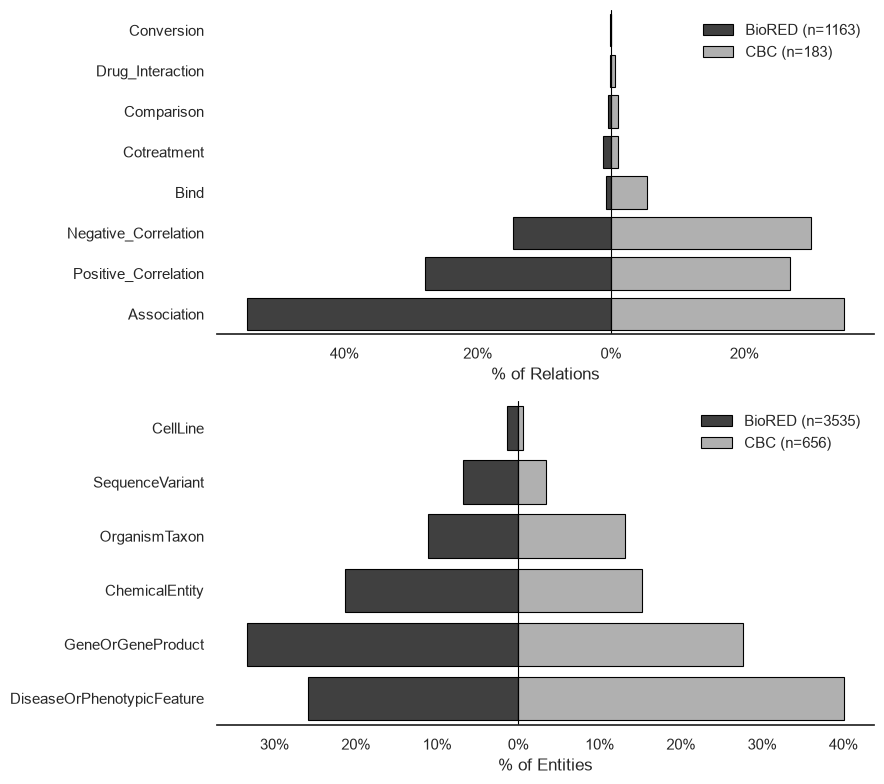

In [6]:
fig, axes = dist.plot_gt_distribution_comparison(
    biored_entities=brt_gt_entities,
    cbc_entities=cbc_gt_entities,
    biored_relations=brt_gt_relations,
    cbc_relations=cbc_gt_relations,
)

In [25]:
len(brt_gt_entities["pmid"].unique())

100

,dataset,type,per_abstract
0,BioRED,Entities,35.350000
1,CBC,Entities,13.387755
2,BioRED,Relations,11.630000
3,CBC,Relations,5.545455


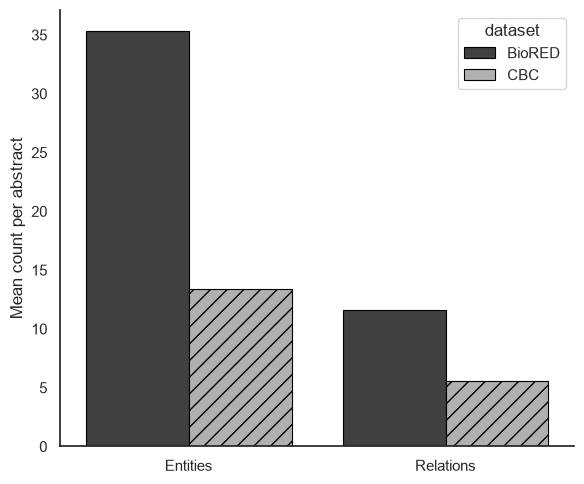

In [ ]:
import matplotlib.pyplot as plt

def plot_gt_ext_num(br_gt_ent, br_gt_rel, cbc_gt_ent, cbc_gt_rel):
    n_biored_ent, n_cbc_ent = len(br_gt_ent), len(cbc_gt_ent)
    n_biored_rel, n_cbc_rel = len(br_gt_rel), len(cbc_gt_rel)

    p_biored_ent = n_biored_ent / len(br_gt_ent["pmid"].unique())
    p_biored_rel = n_biored_rel / len(br_gt_rel["pmid"].unique())
    p_cbc_ent = n_cbc_ent / len(cbc_gt_ent["pmid"].unique())
    p_cbc_rel = n_cbc_rel / len(cbc_gt_rel["pmid"].unique())

    df = pd.DataFrame({
        "dataset": ["BioRED", "CBC", "BioRED", "CBC"],
        "type": ["Entities", "Entities", "Relations", "Relations"],
        "per_abstract": [p_biored_ent, p_cbc_ent, p_biored_rel, p_cbc_rel]
    })

    display(df)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.barplot(
        data=df,
        x="type",
        y="per_abstract",
        hue="dataset",
        palette={"BioRED": "#404040", "CBC": "#b0b0b0"},
        edgecolor="black",
        linewidth=0.8,
        ax=ax,
    )

    for bars, hatch in zip(ax.containers, ["", "//"]):
        for bar in bars:
            bar.set_hatch(hatch)

    ax.set_xlabel("")
    ax.set_ylabel("Mean count per abstract")
    sns.despine(ax=ax)
    fig.tight_layout()
    return fig, ax


fig, ax = plot_gt_ext_num(
    brt_gt_entities,
    brt_gt_relations,
    cbc_gt_entities,
    cbc_gt_relations
)